<font size="5"><center>Taller de procesamiento de señales

<font size="5">Trabajo práctico N°5

<font size="5">Alumno: Santiago Cabrera

<font size="5">Padrón: 110.445

In [337]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import softmax

#a) Creación del dataset

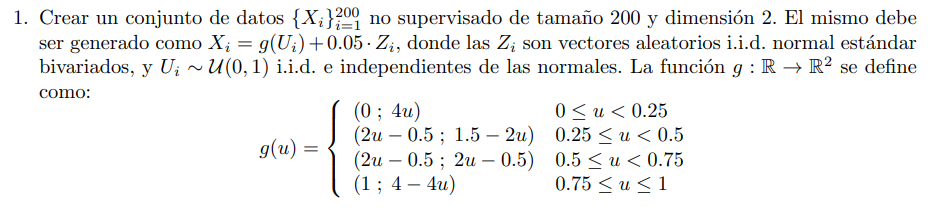

In [338]:
def g(u):
  result = np.zeros((2,))
  if (u >= 0) and (u < 0.25):
    result[0] = 0
    result[1] = 4*u
    return result

  if (u >= 0.25) and (u < 0.5):
    result[0] = 2*u-0.5
    result[1] = 1.5 - 2*u
    return result

  if (u >= 0.5) and (u < 0.75):
    result[0] = 2*u - 0.5
    result[1] = 2*u - 0.5
    return result

  if (u >= 0.75) and (u <= 1):
    result[0] = 1
    result[1] = 4 - 4*u
    return result

  else:
    return None


In [339]:
N = 200
U = np.random.uniform(low = 0, high = 1, size = (N,))
Z = np.random.multivariate_normal(mean = [0,0], cov = [[1,0],[0,1]], size = (N,))
X = np.array([g(u) for u in U]) + 0.05*Z

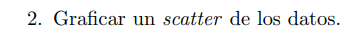

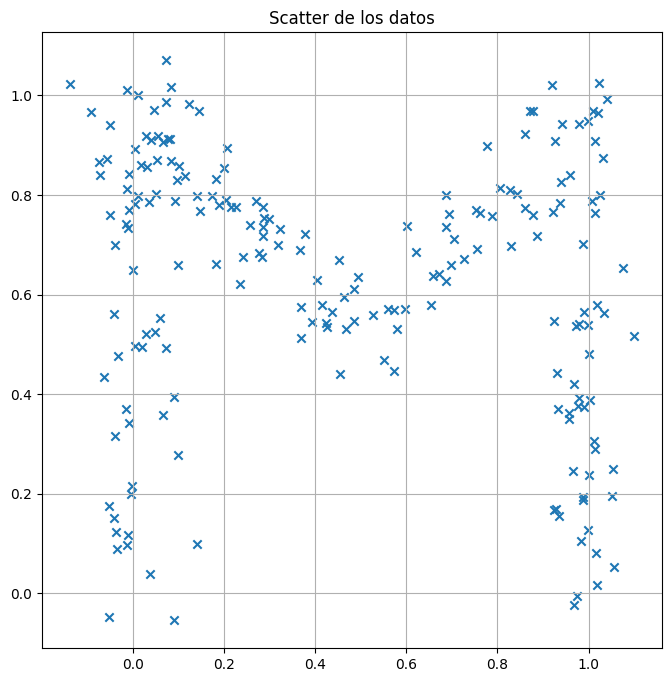

In [340]:
plt.figure(figsize = (8,8))
plt.scatter(X[:, 0], X[:, 1], marker = 'x')
plt.grid(True)
plt.title('Scatter de los datos')
plt.show()

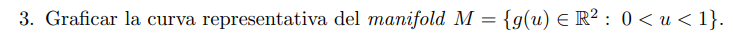

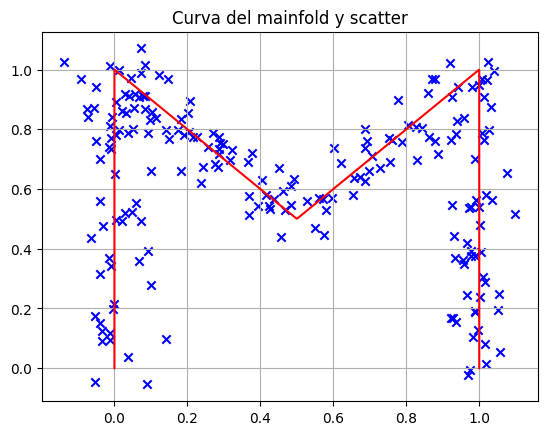

In [341]:
u_arr = np.linspace(start = 0, stop = 1, num = 1000)
g_arr = np.array([g(u) for u in u_arr])
plt.plot(g_arr[:, 0], g_arr[:, 1], 'r-')
plt.scatter(X[:, 0], X[:, 1], marker = 'x', c = 'b')
plt.title('Curva del mainfold y scatter')
plt.grid(True)
plt.show()

#b)

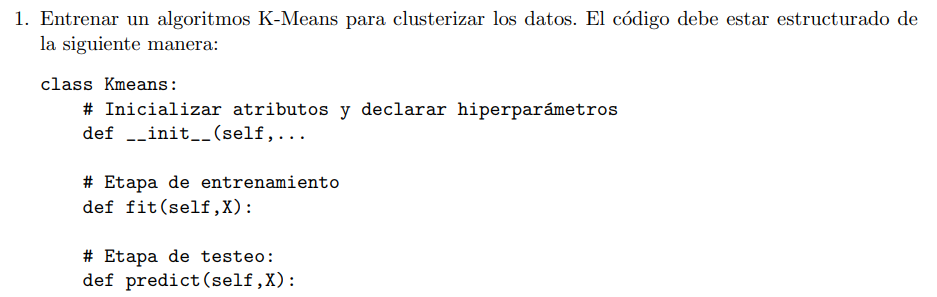

In [342]:
class Kmeans:
  def __init__(self, K, n_iter):
    self.K = K
    self.n_iter = n_iter
    self.means = None #centroides
    self.etiquetas = None

  def fit(self, X):
    #X tiene dimensión (n,m). Cada dato es una fila, hay n datos, cada uno de los cuales tiene m columnas
    indices_random = np.random.choice(X.shape[0], size = self.K, replace = False)
    #obs: K debe ser menor a n
    self.means = X[indices_random, :] #matriz de (k, m)

    self.etiquetas = np.zeros(shape = (X.shape[0], ))

    n = X.shape[0]#número de datos
    m = X.shape[1]#número de características

    iter = 0
    while(iter < self.n_iter):

      X_reshape = X.reshape(n, 1, m)
      centroides_reshape = self.means.reshape(1, self.K, m)
      #hago este cambio de dimensión para poder calcular las distancias sin un for
      distancias = np.linalg.norm(X_reshape - centroides_reshape, axis = 2) #(n, K)
      self.etiquetas = np.argmin(distancias, axis = 1) #(n,)

      #recalculo los centroides
      for k in range(self.K):
        cluster_data = X[self.etiquetas == k] #datos en el cluster k
        #DUDA: qué pasa si un cluster queda vacío? Es decir ¿qué pasa si self.etiquetas == k no devuelve nada?
        if(cluster_data.shape[0] > 0):
          self.means[k, :] = np.mean(cluster_data, axis = 0)
        else:
          self.means[k, :] = self.means[k, :]
          #Si un cluster queda vacío, el centroide no se mueve.

      iter += 1

    return self.means, self.etiquetas

  def predict(self, X):
    n = X.shape[0]
    m = X.shape[1]

    X_reshape = X.reshape(n, 1, m)
    centroides_reshape = self.means.reshape(1, self.K, m)
    distancias = np.linalg.norm(X_reshape - centroides_reshape, axis = 2)

    etiquetas = np.argmin(distancias, axis = 1)
    return etiquetas

In [343]:
K = 4
k_means = Kmeans(K, 500)
centroides, etiquetas = k_means.fit(X)

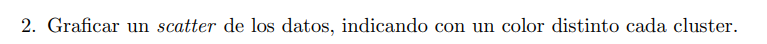

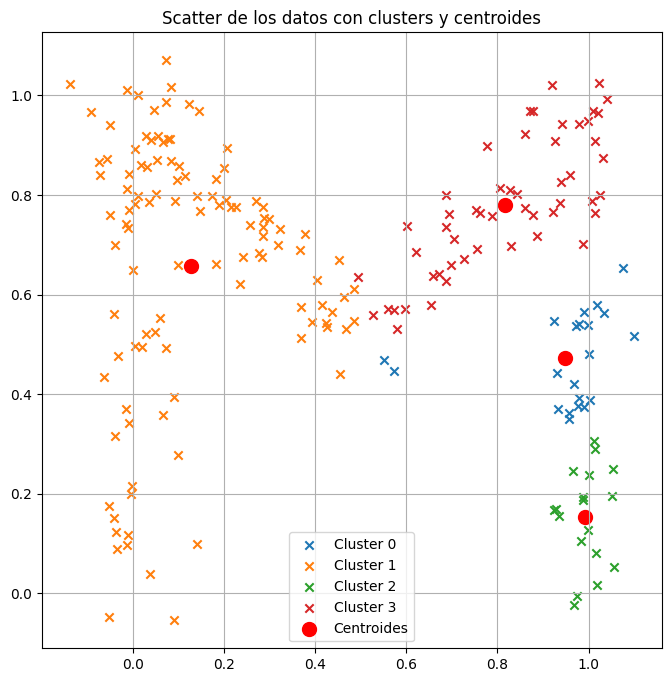

In [344]:
plt.figure(figsize = (8,8))

for k in range(K):
    cluster_data = X[etiquetas == k]
    plt.scatter(cluster_data[:, 0], cluster_data[:, 1], marker='x', label=f'Cluster {k}')


plt.scatter(centroides[:, 0], centroides[:, 1], marker='o', color='red', s=100, label='Centroides')

plt.grid(True)
plt.title('Scatter de los datos con clusters y centroides')
plt.legend()
plt.show()

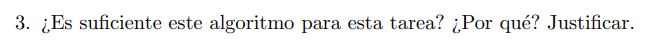

El algoritmo de Kmeans no es suficiente para esta tarea porque no aprende las 4 curvas del mainfold del dataset. Esto se debe a que, al usar la norma euclídea, el algoritmo tiende a agrupar los datos en círculos. Esto se ajusta mal a nuestro dataset.

#c) Algoritmo EM

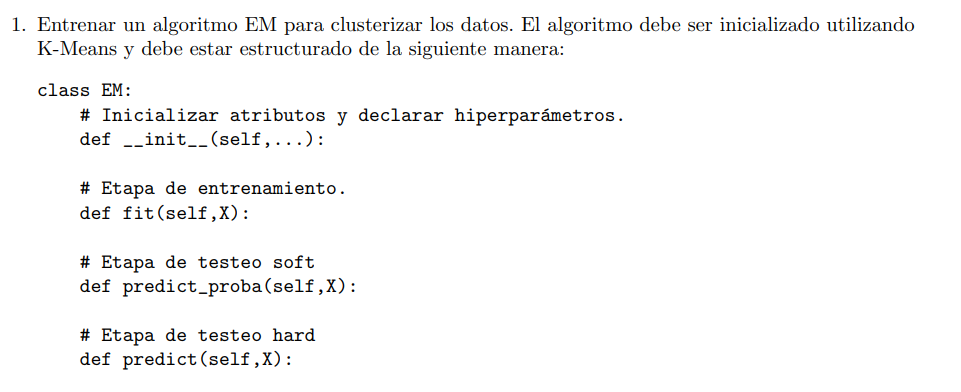

DUDA: Cuando recalculo las matrices de covarianza ¿lo hago antes o después de actualizar las medias?

Creo que tiene más sentido si lo hago antes

In [345]:
class EM:
  def __init__(self, K, n_iter, n_iter_kmeans):
    self.n_iter = n_iter
    self.K = K
    self.medias = None
    self.covarianzas = None
    self.c_k = None #pesos
    self.kmeans = Kmeans(self.K, n_iter = n_iter_kmeans)

  def fit(self, X):
    #Paso 0. Inicializo los parámetros de mis K distribuciones gaussianas con Kmeans

    self.medias, etiquetas = self.kmeans.fit(X)

    n, m = X.shape #n = cantidad de datos. m = características por dato

    self.covarianzas = np.zeros((self.K, m, m))
    self.c_k = np.zeros(self.K)

    for k in range(self.K):
      data_cluster = X[etiquetas == k] #¿Qué pasa si el cluster está vacío?
      self.covarianzas[k] = np.cov(data_cluster, rowvar = False)

      self.c_k[k] = data_cluster.shape[0] / n #la cantidad de datos en cada cluster dividido la cantidad de datos totales

    #fin paso 0

    n_iter = 0
    while n_iter < self.n_iter:
      n_iter += 1

      #Paso E. Calcula la probabilidad de pertenencia a cada gaussiana

      p_x_k = np.zeros((n, self.K))
      for k in range(self.K):
        diff = X - self.medias[k]
        inv_cov = np.linalg.inv(self.covarianzas[k])
        exp = np.sum(-0.5 * diff @ inv_cov * diff, axis = 1)

        p_x_k[:, k] = self.c_k[k] * np.exp(exp) / ((2 * np.pi) ** (m / 2) * np.sqrt(np.linalg.det(self.covarianzas[k])))


      q = p_x_k / np.sum(p_x_k, axis = 1, keepdims = True) #(200, k)

      #Fin paso E


      #Paso M:

      #recalculo pesos
      self.c_k = np.mean(q, axis = 0)

      #recalculo covarianzas
      for k in range(self.K):
        diff = X - self.medias[k] #(200, m)
        pesos = q[:, k].reshape(n, 1) #(200, 1)
        #numerador: suma_i q(k|x_i) * (diff)(diff))^T
        self.covarianzas[k] = (diff.T @ (pesos * diff)) / np.sum(pesos)

      #recalculo medias
      den = np.sum(q, axis = 0)
      self.medias = q.T @ X / den.reshape(len(den), 1) #división elemento a elemento. Necesito reshape

      #fin paso M

  def predict_proba(self, X):
    n, m = X.shape
    probas = np.zeros((n, self.K)) #en cada dato calculo la proba de pertenecer al cluster k

    for k in range(self.K):
      diff = X - self.medias[k]
      inv_cov = np.linalg.inv(self.covarianzas[k])
      exp = np.sum(-0.5 * diff @ inv_cov * diff, axis = 1)

      probas[:, k] = self.c_k[k] * np.exp(exp)

    return probas / np.sum(probas, axis = 1, keepdims = True)

  def predict(self, X):
    probas = self.predict_proba(X)
    return np.argmax(probas, axis = 1)

In [346]:
ex_max = EM(K = K, n_iter = 1000, n_iter_kmeans = 100)
ex_max.fit(X)
etiquetas = ex_max.predict(X)

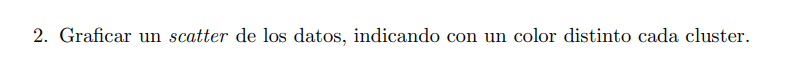

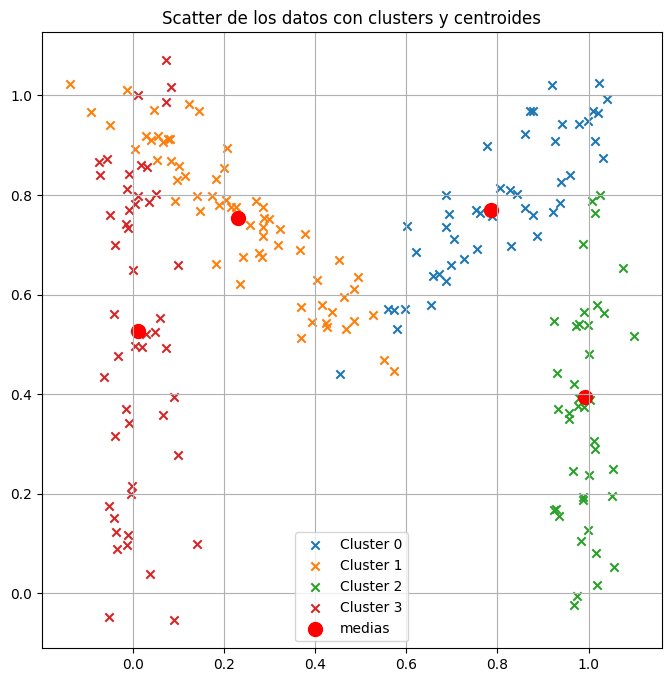

In [347]:
plt.figure(figsize = (8,8))

for k in range(K):
    cluster_data = X[etiquetas == k]
    plt.scatter(cluster_data[:, 0], cluster_data[:, 1], marker='x', label=f'Cluster {k}')

medias = ex_max.medias
plt.scatter(medias[:, 0], medias[:, 1], marker='o', color='red', s=100, label='medias')

plt.grid(True)
plt.title('Scatter de los datos con clusters y centroides')
plt.legend()
plt.show()

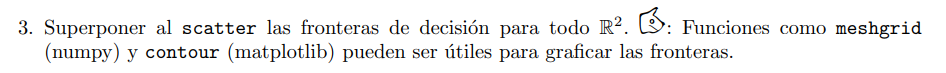

In [348]:
e = 0.25
x_min, x_max = X[:, 0].min() - e, X[:, 0].max() + e
y_min, y_max = X[:, 1].min() - e, X[:, 1].max() + e
puntos = 1000
xx, yy = np.meshgrid(np.linspace(x_min, x_max, puntos),
                     np.linspace(y_min, y_max, puntos))
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = ex_max.predict(grid_points)
Z = Z.reshape(xx.shape)

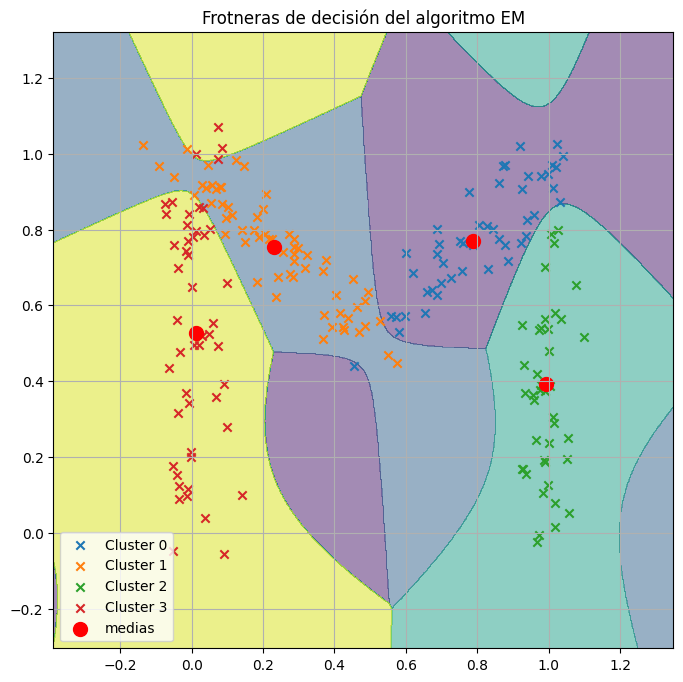

In [349]:
plt.figure(figsize = (8,8))

plt.contourf(xx, yy, Z, cmap = 'viridis', alpha = 0.5)

for k in range(K):
    cluster_data = X[etiquetas == k]
    plt.scatter(cluster_data[:, 0], cluster_data[:, 1], marker='x', label=f'Cluster {k}')

medias = ex_max.medias
plt.scatter(medias[:, 0], medias[:, 1], marker='o', color='red', s=100, label='medias')

plt.grid(True)
plt.title('Frotneras de decisión del algoritmo EM')
plt.legend()
plt.show()

Para comparar, grafico la frontera de decisión de Kmeans

In [350]:
Z = k_means.predict(grid_points)
Z = Z.reshape(xx.shape)
etiquetas = k_means.predict(X)

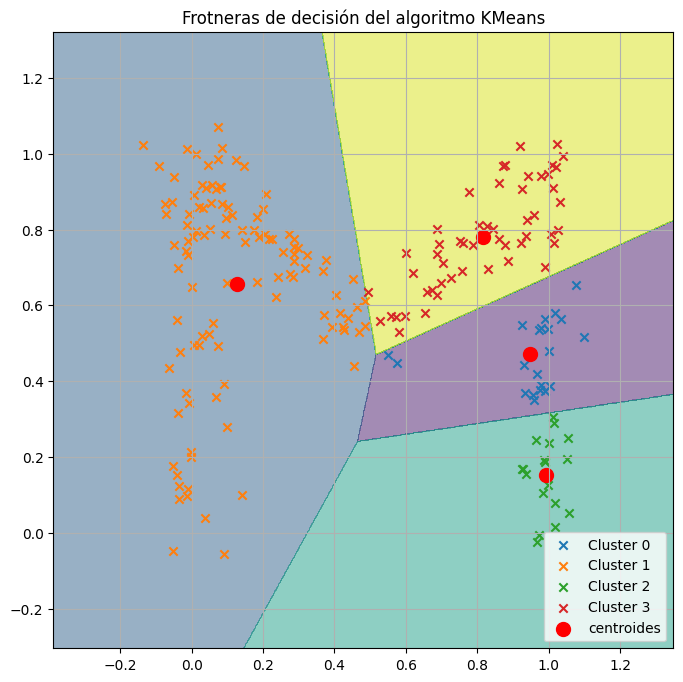

In [351]:
plt.figure(figsize = (8,8))

plt.contourf(xx, yy, Z, cmap = 'viridis', alpha = 0.5)

for k in range(K):
    cluster_data = X[etiquetas == k]
    plt.scatter(cluster_data[:, 0], cluster_data[:, 1], marker='x', label=f'Cluster {k}')

centroides = k_means.means
plt.scatter(centroides[:, 0], centroides[:, 1], marker='o', color='red', s=100, label='centroides')

plt.grid(True)
plt.title('Frotneras de decisión del algoritmo KMeans')
plt.legend()
plt.show()

Observaciones: El algoritmo KMeans solo es capaz de producir fronteras lineales. Esto se debe a que las curvas de nivel quedan determinadas por intersecciones entre círculos. Eso produce que las fronteras de decisión queden definidas por las recta de puntos equdistantes a 2 centroides.

En cambio, el algoritmo EM es capaz de producir fronteras elípticas. Esto se debe a que las fronteras de decisión en EM quedan determinadas por interescciones entre elipses, cuyos ejes están determinados por las matrices de covarianza de la distribución gaussiana de cada cluster.

#d) PCA

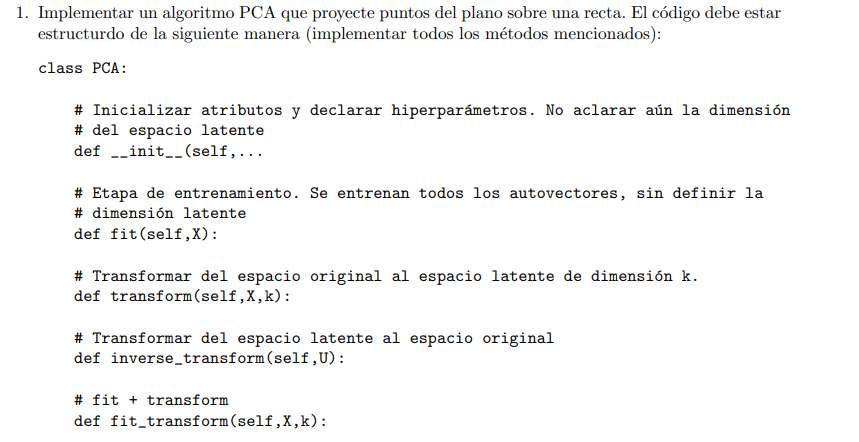

In [352]:

class PCA:
  def __init__ (self, n_componentes = 1, whiten = False):
    self.n_componentes = n_componentes
    self.whiten = whiten
    self.avas = None #array de autovalores
    self.aves = None #matriz de autovectores

    self.medias = None

    self.avas_principales = None
    self.componentes_principales = None #Matriz con los vectores de las componentes principales

  def fit(self, X):

    self.medias = np.mean(X, axis = 0)
    if(self.whiten):
      X_escalado = (X - self.medias)/np.std(X, axis = 0)
      cov = np.cov(X_escalado, rowvar = False)
    else:
      X_centrado = X - self.medias
      cov = np.cov(X_centrado, rowvar = False)

    avas, aves = np.linalg.eigh(cov) #eigh calcula los avas y aves para una matriz hermítica (real simétrica)
    #los aves están ordenados de forma ascendente
    self.avas = np.flip(avas)
    self.aves = np.flip(aves, axis = 1)

    self.avas_principales = self.avas[:self.n_componentes]
    self.componentes_principales = self.aves[:, :self.n_componentes]

  def transform(self, X):
    X_transformado = (X - self.medias) @ self.componentes_principales
    #X_transformado = (X - np.mean(X, axis = 0)) @ self.componentes_principales
    return X_transformado

  def inverse_transform(self, X):
    X_inversa = X @ self.componentes_principales.T + self.medias
    return X_inversa

  def fit_transform(self, X):
    self.fit(X)
    return self.transform(X)

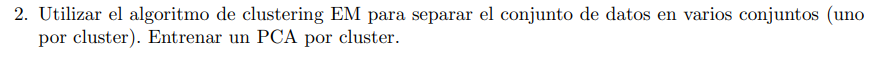

In [353]:
ex_max.fit(X)
etiquetas = ex_max.predict(X)

#Entreno un pca por cluster. Guardo todo en un diccionario. Cada entrada del diccionario tiene los datos del cluster y la clase PCA de ese cluster
clusters_dict = {}
for k in range(K):
    cluster_data = X[etiquetas == k]
    pca = PCA(n_componentes = 1)
    pca.fit(cluster_data)
    clusters_dict[f'Cluster{k}'] = [cluster_data, pca]

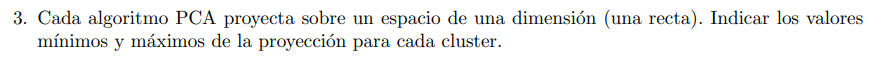

In [354]:
for key in clusters_dict.keys():
  cluster_data, pca = clusters_dict[key]
  proyeccion = pca.transform(cluster_data)
  max = np.max(proyeccion)
  min = np.min(proyeccion)
  print(f'Para {key}, la máxima poryeccion es {max}')
  print(f'Para {key}, la minima poryeccion es {min}\n')

Para Cluster0, la máxima poryeccion es 0.46425935599809875
Para Cluster0, la minima poryeccion es -0.45115177595741535

Para Cluster1, la máxima poryeccion es 0.43913377170432927
Para Cluster1, la minima poryeccion es -0.38555632709309867

Para Cluster2, la máxima poryeccion es 0.48936261875548226
Para Cluster2, la minima poryeccion es -0.3242219511219418

Para Cluster3, la máxima poryeccion es 0.5400090843366964
Para Cluster3, la minima poryeccion es -0.5851120502544078



Cada algortimo PCA trabaja centrado en una media. Estos datos muestran la máxima desviación respecto de esa media vista en los datos de entrenamiento.

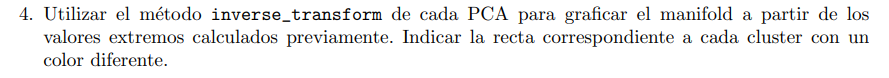

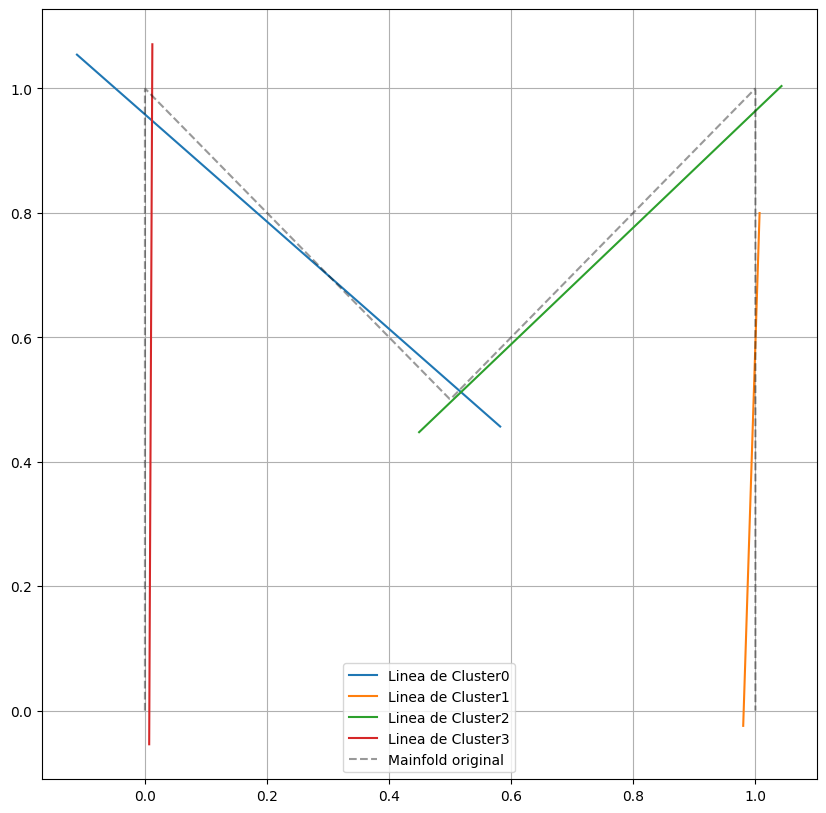

In [355]:
plt.figure(figsize=(10, 10))

for key in clusters_dict.keys():
  cluster_data, pca = clusters_dict[key]
  proyeccion = pca.transform(cluster_data)
  max = np.max(proyeccion).reshape(1, 1)
  min = np.min(proyeccion).reshape(1, 1)
  vector_max = pca.inverse_transform(max)
  vector_min = pca.inverse_transform(min)

  # Plot the line connecting vector_min and vector_max
  plt.plot([vector_min[0, 0], vector_max[0, 0]], [vector_min[0, 1], vector_max[0, 1]], '-', label = f'Linea de {key}')

plt.plot(g_arr[:, 0], g_arr[:, 1], 'k--', alpha = 0.4, label = 'Mainfold original')

plt.grid(True)
plt.legend()
plt.show()

Se reconstruyen las máximas y mínimas proyecciones vistas en el entrenamiento. Eso da 2 vectores por cluster.

La linea que une estos 2 vectores muestra la dirección prinicpal aprendida. Las superposición de las direcciones principales aprendidas por cada clase PCA reconstruyen el mainfold.

#e) Detector de anomalías

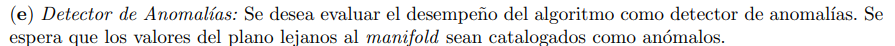

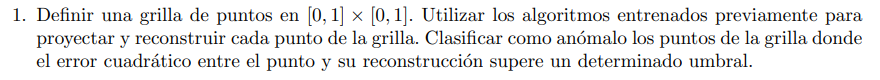

In [356]:
puntos = 100
xx, yy = np.meshgrid(np.linspace(0, 1, puntos),
                     np.linspace(0, 1, puntos))
puntos_grilla = np.c_[xx.ravel(), yy.ravel()]
print(xx.shape, yy.shape, puntos_grilla.shape)
#el vector (xx[i, j], yy[i, j]) representa el punto (i, j) de la grilla
#La matriz puntos_grilla es de (puntosxpuntos, 2). Cada fila es un punto. Es lo que le puedo pasar a los algoritmos

(100, 100) (100, 100) (10000, 2)


Tengo 4 clases PCA para determinar si un punto es anómalo o no.

Un punto es no anómalo si por lo menos una clase determina que el punto no es anómalo

In [357]:
no_es_anomalo = np.zeros(shape = puntos_grilla.shape[0], dtype = bool)
umbral = 0.01
for key in clusters_dict.keys():
    cluster_data, pca = clusters_dict[key]

    puntos_cod = pca.transform(puntos_grilla) #puntos codificados
    puntos_decod = pca.inverse_transform(puntos_cod) #puntos decodificados

    ECM = np.linalg.norm(puntos_grilla - puntos_decod, axis = 1)
    no_es_anomalo = no_es_anomalo | (ECM < umbral)

print(no_es_anomalo.reshape(xx.shape))

[[ True  True False ...  True  True False]
 [ True  True False ...  True  True False]
 [ True  True False ...  True  True False]
 ...
 [False  True  True ... False False False]
 [False  True  True ... False False False]
 [False  True  True ... False False False]]


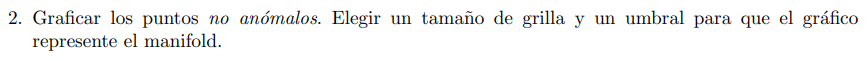

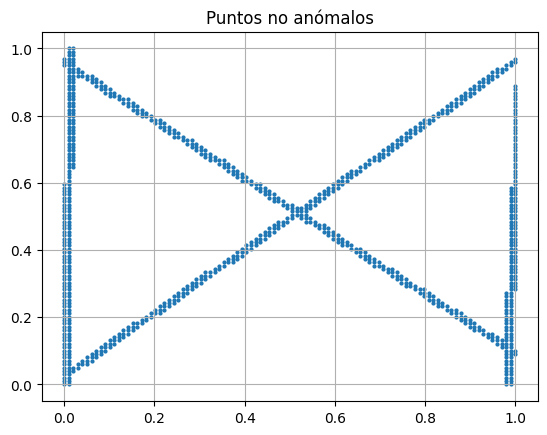

In [358]:
puntos_no_anomalos = puntos_grilla[no_es_anomalo]

plt.scatter(puntos_no_anomalos[:, 0], puntos_no_anomalos[:, 1], s = 4, marker = 'o')
plt.title('Puntos no anómalos')
plt.grid(True)
plt.show()

Se observa que la reconstrucción se parece ael mainfold, pero no es del todo correcta.

Esto se debe a que solo se consideró la proyección sobre la dirección principal aprendida, sin considerar cuales fueron los valores máximos y mínimos vistos durante el entrenamiento. De esta forma, un punto que esté cerca de la dirección principal aprendida será considerado no anomalo, aunque esté muy alejado del cluster original que produjo dicha dirección principal.

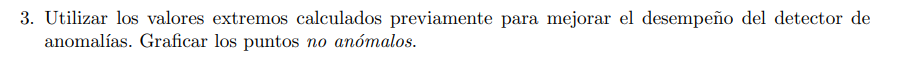

In [359]:
no_es_anomalo = np.zeros(shape = puntos_grilla.shape[0], dtype = bool)

for key in clusters_dict.keys():
    cluster_data, pca = clusters_dict[key]

    proyeccion = pca.transform(cluster_data)
    max = np.max(proyeccion)
    min = np.min(proyeccion)

    puntos_cod = pca.transform(puntos_grilla) #puntos codificados
    mascara = np.logical_and(puntos_cod > min, puntos_cod < max).reshape(-1, )
    #guardo los índices de los puntos que estén dentro de los rangos vistos en el entrenamiento. Negando estos indices obtengo los puntos excedidos
    mascara_puntos_excedidos = np.logical_not(mascara)
    puntos_decod = pca.inverse_transform(puntos_cod) #puntos decodificados


    ECM = np.linalg.norm(puntos_grilla - puntos_decod, axis = 1)
    ECM[np.where(mascara_puntos_excedidos)] = np.inf #si el punto excedió los límites, asigno si ECM en inifinito
    no_es_anomalo = no_es_anomalo | (ECM < umbral)


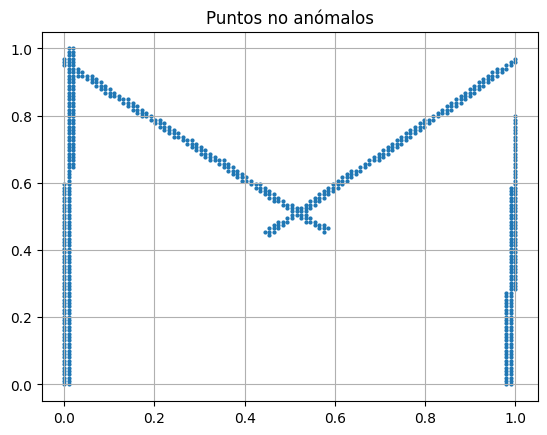

In [360]:
puntos_no_anomalos = puntos_grilla[no_es_anomalo]

plt.scatter(puntos_no_anomalos[:, 0], puntos_no_anomalos[:, 1], s = 4, marker = 'o')
plt.title('Puntos no anómalos')
plt.grid(True)
plt.show()

Se observa el mainfold original.

Se concluye que a la hora de decodificar un dato en PCA no solo importa la dirección principal aprendida, sino también los valores extremos observados en los datos de entrenamiento.